# Parte 2 — Análisis descriptivo, segmentación y diagnóstico de Trujillo

**Proyecto:** AndinaRetail S.A.C.  
**Notebook:** `notebooks/02_descriptivo_diagnostico.ipynb`  
**Dataset:** oficial v1 congelado en `datos/`  
**Salidas:** `resultados/segmentacion_clientes.csv` y `resultados/diagnostico_trujillo.csv`

Este notebook implementa la Parte 2 del proyecto. El objetivo es explicar patrones históricos, segmentos de clientes y causas de la caída de margen operativo en Trujillo desde 2025-Q2. El flujo respeta el dataset oficial v1, las fórmulas del diccionario de datos y la especificación analítica del proyecto.

## 1. Configuración y reproducibilidad

Se fijan rutas relativas al repositorio. El notebook no modifica los CSV oficiales: solo lee los archivos fuente congelados y exporta resultados derivados en `resultados/`.

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 2026
rng = np.random.default_rng(SEED)

CURRENT = Path.cwd()
ROOT = CURRENT.parent if CURRENT.name == "notebooks" else CURRENT
DATA_DIR = ROOT / "datos"
RESULTS_DIR = ROOT / "resultados"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATHS = {
    "tiendas": DATA_DIR / "tiendas.csv",
    "productos": DATA_DIR / "productos.csv",
    "clientes": DATA_DIR / "clientes.csv",
    "ventas": DATA_DIR / "ventas.csv",
    "inventario": DATA_DIR / "inventario.csv",
}

OUT_SEGMENTACION = RESULTS_DIR / "segmentacion_clientes.csv"
OUT_DIAGNOSTICO = RESULTS_DIR / "diagnostico_trujillo.csv"

pd.options.display.float_format = "{:,.4f}".format

print(f"ROOT: {ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"RESULTS_DIR: {RESULTS_DIR}")

ROOT: C:\Users\ca\OneDrive\Desktop\proyecto-andinaretail
DATA_DIR: C:\Users\ca\OneDrive\Desktop\proyecto-andinaretail\datos
RESULTS_DIR: C:\Users\ca\OneDrive\Desktop\proyecto-andinaretail\resultados


## 2. Evidencia del dataset oficial v1

Se verifica la existencia de los cinco CSV oficiales, el archivo de versión del dataset y el reporte de validación. Esta sección sirve como control antes de construir análisis derivados.

In [2]:
for nombre, ruta in CSV_PATHS.items():
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el CSV requerido: {ruta}")
    print(f"[OK] {nombre}: {ruta.relative_to(ROOT)}")

version_path = DATA_DIR / "DATASET_VERSION.md"
validation_report = RESULTS_DIR / "reporte_validacion_datos.txt"

if version_path.exists():
    print("\nDATASET_VERSION.md:")
    print("\n".join(version_path.read_text(encoding="utf-8").splitlines()[:18]))
else:
    print("\n[WARN] No se encontró datos/DATASET_VERSION.md")

if validation_report.exists():
    print("\nReporte de validación:")
    reporte = validation_report.read_text(encoding="utf-8")
    for linea_reporte in reporte.splitlines()[:8]:
        print(linea_reporte)
else:
    print("\n[WARN] No se encontró resultados/reporte_validacion_datos.txt")

[OK] tiendas: datos\tiendas.csv
[OK] productos: datos\productos.csv
[OK] clientes: datos\clientes.csv
[OK] ventas: datos\ventas.csv
[OK] inventario: datos\inventario.csv

DATASET_VERSION.md:
# Dataset oficial v1 — AndinaRetail S.A.C.

## Estado

Dataset oficial congelado para las Partes 1 a 5 del proyecto.

## Versión

- Versión del dataset: v1
- Semilla de generación: 2026
- Versión de configuración: 1.3.0
- Estado de validación: APROBADO

## Archivos congelados

- `datos/tiendas.csv`
- `datos/productos.csv`
- `datos/clientes.csv`

Reporte de validación:
Reporte de validacion de datos — AndinaRetail S.A.C.
Estado general: APROBADO
Version config: 1.3.0
Semilla: 2026

Validaciones correctas: 121
Advertencias: 1


## 3. Carga de datos

Se cargan las cinco tablas oficiales: `tiendas`, `productos`, `clientes`, `ventas` e `inventario`.

In [3]:
tiendas = pd.read_csv(CSV_PATHS["tiendas"])
productos = pd.read_csv(CSV_PATHS["productos"])
clientes = pd.read_csv(CSV_PATHS["clientes"])
ventas = pd.read_csv(CSV_PATHS["ventas"])
inventario = pd.read_csv(CSV_PATHS["inventario"])

tablas = {
    "tiendas": tiendas,
    "productos": productos,
    "clientes": clientes,
    "ventas": ventas,
    "inventario": inventario,
}

resumen_carga = pd.DataFrame({
    "tabla": list(tablas.keys()),
    "filas": [len(df) for df in tablas.values()],
    "columnas": [df.shape[1] for df in tablas.values()],
})
display(resumen_carga)

,tabla,filas,columnas
0,tiendas,15,8
1,productos,800,8
2,clientes,15000,9
3,ventas,250000,12
4,inventario,432000,8


## 4. Preparación de vistas derivadas

Se construyen vistas a nivel de línea de venta, ticket, cliente y agregados mensuales. Las métricas financieras se calculan con las fórmulas oficiales del diccionario de datos.

In [4]:
# Copias de trabajo para no alterar las tablas originales.
tiendas = tiendas.copy()
productos = productos.copy()
clientes = clientes.copy()
ventas = ventas.copy()
inventario = inventario.copy()

ventas["fecha_dt"] = pd.to_datetime(ventas["fecha"])
clientes["fecha_registro_dt"] = pd.to_datetime(clientes["fecha_registro"])

productos_min = productos[["id_producto", "nombre", "categoria", "subcategoria", "marca", "precio_lista", "costo_unitario"]].copy()
tiendas_min = (
    tiendas[["id_tienda", "nombre", "tipo", "canal", "ciudad", "region"]]
    .rename(columns={
        "nombre": "nombre_tienda",
        "canal": "canal_tienda",
        "ciudad": "ciudad_tienda",
        "region": "region_tienda",
    })
)
clientes_min = clientes[["id_cliente", "ciudad", "segmento", "canal_preferido", "edad", "genero"]].rename(
    columns={
        "ciudad": "ciudad_cliente",
        "segmento": "segmento_comercial",
        "canal_preferido": "canal_preferido_cliente",
        "edad": "edad_cliente",
        "genero": "genero_cliente",
    }
)

# Vista línea enriquecida.
linea = (
    ventas
    .merge(productos_min, on="id_producto", how="left")
    .merge(tiendas_min, on="id_tienda", how="left")
    .merge(clientes_min, on="id_cliente", how="left")
)

linea["venta_bruta"] = linea["cantidad"] * linea["precio_unitario"]
linea["descuento_monto"] = linea["venta_bruta"] * linea["descuento_pct"]
linea["costo_mercaderia"] = linea["cantidad"] * linea["costo_unitario"]
linea["margen_bruto"] = linea["monto_total"] - linea["costo_mercaderia"]
linea["margen_bruto_pct"] = linea["margen_bruto"] / linea["monto_total"]
linea["grupo_canal"] = np.where(linea["canal"].eq("Tienda"), "Fisico", "Digital")
linea["ciudad_venta"] = np.where(linea["canal"].eq("Tienda"), linea["ciudad_tienda"], linea["ciudad_cliente"])
linea["periodo_mes"] = linea["fecha_dt"].dt.to_period("M").astype(str)
linea["trimestre"] = linea["fecha_dt"].dt.to_period("Q").astype(str)
linea["anio"] = linea["fecha_dt"].dt.year
linea["mes"] = linea["fecha_dt"].dt.month

# Vista ticket.
ticket = (
    linea.groupby("id_venta", as_index=False)
    .agg(
        fecha=("fecha", "first"),
        fecha_dt=("fecha_dt", "first"),
        id_cliente=("id_cliente", "first"),
        id_tienda=("id_tienda", "first"),
        canal=("canal", "first"),
        grupo_canal=("grupo_canal", "first"),
        ciudad_venta=("ciudad_venta", "first"),
        metodo_pago=("metodo_pago", "first"),
        ticket_total=("monto_total", "sum"),
        cantidad_total=("cantidad", "sum"),
        lineas_ticket=("id_linea", "count"),
    )
)
ticket["periodo_mes"] = ticket["fecha_dt"].dt.to_period("M").astype(str)
ticket["trimestre"] = ticket["fecha_dt"].dt.to_period("Q").astype(str)

# Categoría principal por ticket para análisis de concentración.
categoria_ticket = (
    linea.groupby(["id_venta", "categoria"], as_index=False)["monto_total"]
    .sum()
    .sort_values(["id_venta", "monto_total", "categoria"], ascending=[True, False, True])
    .drop_duplicates("id_venta")
    [["id_venta", "categoria"]]
    .rename(columns={"categoria": "categoria_ticket"})
)
ticket = ticket.merge(categoria_ticket, on="id_venta", how="left")

# Inventario enriquecido.
inventario["periodo_mes"] = inventario["periodo"].astype(str)
inventario["trimestre"] = pd.PeriodIndex(inventario["periodo_mes"], freq="M").asfreq("Q").astype(str)
inventario_enriquecido = (
    inventario
    .merge(tiendas_min, on="id_tienda", how="left")
    .merge(productos[["id_producto", "categoria", "costo_unitario"]], on="id_producto", how="left")
)

print("Vista línea:", linea.shape)
print("Vista ticket:", ticket.shape)
print("Vista cliente:", clientes.shape)
print("Vista inventario enriquecido:", inventario_enriquecido.shape)

display(linea.head())
display(ticket.head())

Vista línea: (250000, 40)
Vista ticket: (100000, 15)
Vista cliente: (15000, 10)
Vista inventario enriquecido: (432000, 17)


,id_linea,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento_pct,monto_total,...,descuento_monto,costo_mercaderia,margen_bruto,margen_bruto_pct,grupo_canal,ciudad_venta,periodo_mes,trimestre,anio,mes
0,L0000001,V000001,2025-03-02,C14714,WEB,P0362,1,72.6400,0.0490,69.0800,...,3.5594,51.1400,17.9400,0.2597,Digital,Trujillo,2025-03,2025Q1,2025,3
1,L0000002,V000001,2025-03-02,C14714,WEB,P0486,7,157.5000,0.1796,904.4900,...,198.0090,694.6800,209.8100,0.2320,Digital,Trujillo,2025-03,2025Q1,2025,3
2,L0000003,V000002,2023-07-06,C12369,T001,P0520,2,63.4000,0.0918,115.1600,...,11.6402,81.9200,33.2400,0.2886,Fisico,Lima,2023-07,2023Q3,2023,7
3,L0000004,V000002,2023-07-06,C12369,T001,P0493,1,177.1000,0.0000,177.1000,...,0.0000,117.0400,60.0600,0.3391,Fisico,Lima,2023-07,2023Q3,2023,7
4,L0000005,V000002,2023-07-06,C12369,T001,P0567,3,14.8000,0.1025,39.8500,...,4.5510,27.1200,12.7300,0.3194,Fisico,Lima,2023-07,2023Q3,2023,7


,id_venta,fecha,fecha_dt,id_cliente,id_tienda,canal,grupo_canal,ciudad_venta,metodo_pago,ticket_total,cantidad_total,lineas_ticket,periodo_mes,trimestre,categoria_ticket
0,V000001,2025-03-02,2025-03-02,C14714,WEB,Web,Digital,Trujillo,Tarjeta credito,973.5700,8,2,2025-03,2025Q1,Cuidado Personal
1,V000002,2023-07-06,2023-07-06,C12369,T001,Tienda,Fisico,Lima,Efectivo,332.1100,6,3,2023-07,2023Q3,Cuidado Personal
2,V000003,2023-09-16,2023-09-16,C09839,T009,Tienda,Fisico,Trujillo,Tarjeta debito,"2,030.1600",6,4,2023-09,2023Q3,Electrohogar
3,V000004,2023-09-17,2023-09-17,C00763,T001,Tienda,Fisico,Lima,Efectivo,68.4100,1,1,2023-09,2023Q3,Abarrotes
4,V000005,2025-06-18,2025-06-18,C12552,T011,Tienda,Fisico,Cusco,Tarjeta debito,215.2500,3,1,2025-06,2025Q2,Abarrotes


## 5. Tendencias históricas por tiempo

Se analizan ventas netas, tickets, unidades, descuentos y márgenes por mes. Esto permite observar estacionalidad, crecimiento del canal digital y cambios de rentabilidad.

In [5]:
ventas_mensuales = (
    linea.groupby("periodo_mes", as_index=False)
    .agg(
        ventas_netas=("monto_total", "sum"),
        margen_bruto=("margen_bruto", "sum"),
        descuento_monto=("descuento_monto", "sum"),
        venta_bruta=("venta_bruta", "sum"),
        unidades=("cantidad", "sum"),
        lineas=("id_linea", "count"),
        tickets=("id_venta", "nunique"),
    )
)
ventas_mensuales["margen_bruto_pct"] = ventas_mensuales["margen_bruto"] / ventas_mensuales["ventas_netas"]
ventas_mensuales["descuento_pct_ponderado"] = ventas_mensuales["descuento_monto"] / ventas_mensuales["venta_bruta"]
ventas_mensuales["ticket_promedio"] = ventas_mensuales["ventas_netas"] / ventas_mensuales["tickets"]

display(ventas_mensuales.head())

resumen_tendencia = {
    "ventas_2023": ventas_mensuales.loc[ventas_mensuales["periodo_mes"].str.startswith("2023"), "ventas_netas"].sum(),
    "ventas_2024": ventas_mensuales.loc[ventas_mensuales["periodo_mes"].str.startswith("2024"), "ventas_netas"].sum(),
    "ventas_2025": ventas_mensuales.loc[ventas_mensuales["periodo_mes"].str.startswith("2025"), "ventas_netas"].sum(),
}
crecimiento_2025_vs_2023 = (resumen_tendencia["ventas_2025"] / resumen_tendencia["ventas_2023"] - 1) * 100

texto_tendencia = f"""
**Lectura de negocio.** Las ventas netas acumuladas crecen de 2023 a 2025 en aproximadamente **{crecimiento_2025_vs_2023:.2f}%**. El análisis mensual permite observar los picos estacionales definidos para julio y diciembre, y sirve como base para entender la evolución de margen y demanda en las siguientes secciones.
"""
display(Markdown(texto_tendencia))

,periodo_mes,ventas_netas,margen_bruto,descuento_monto,venta_bruta,unidades,lineas,tickets,margen_bruto_pct,descuento_pct_ponderado,ticket_promedio
0,2023-01,"2,439,105.6600","663,153.7300","100,812.6605","2,539,918.3500",11575,5626,2271,0.2719,0.0397,"1,074.0227"
1,2023-02,"2,193,549.0000","592,332.4700","94,267.4856","2,287,816.6000",9857,4845,1922,0.2700,0.0412,"1,141.2846"
2,2023-03,"2,519,618.9900","686,648.4900","105,321.9560","2,624,941.0200",12597,6130,2469,0.2725,0.0401,"1,020.5018"
3,2023-04,"2,535,741.1800","680,685.4200","115,249.6675","2,650,991.0900",11987,5837,2347,0.2684,0.0435,"1,080.4181"
4,2023-05,"2,821,553.1600","762,780.8900","123,096.3871","2,944,649.5500",13277,6525,2604,0.2703,0.0418,"1,083.5458"



**Lectura de negocio.** Las ventas netas acumuladas crecen de 2023 a 2025 en aproximadamente **10.79%**. El análisis mensual permite observar los picos estacionales definidos para julio y diciembre, y sirve como base para entender la evolución de margen y demanda en las siguientes secciones.


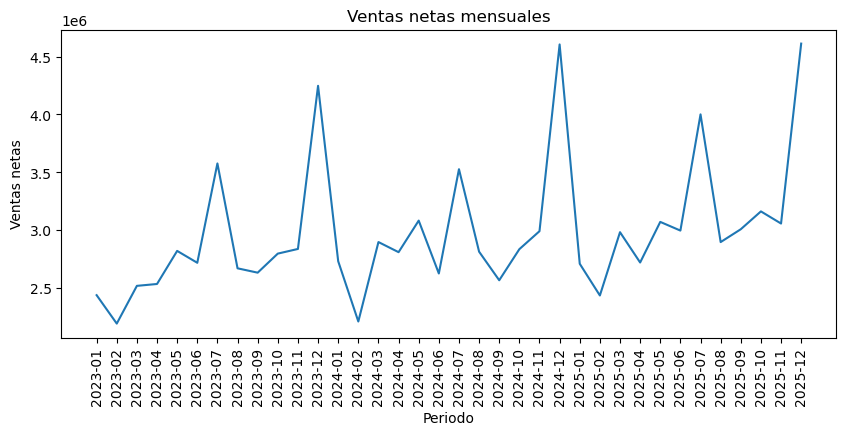

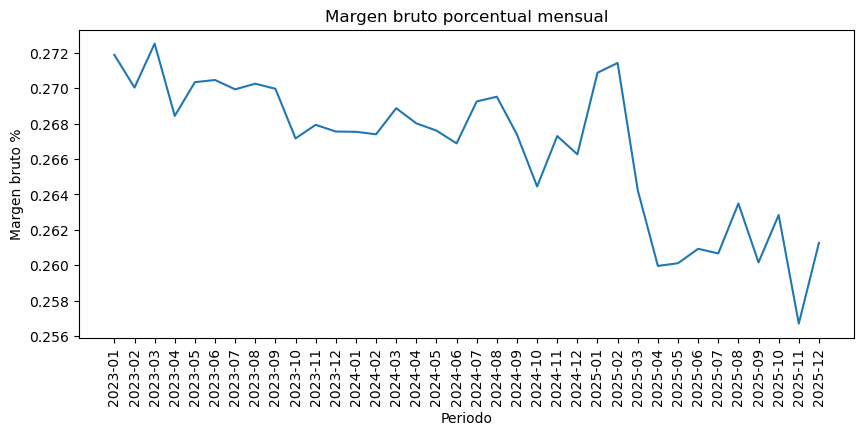

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ventas_mensuales["periodo_mes"], ventas_mensuales["ventas_netas"])
ax.set_title("Ventas netas mensuales")
ax.set_xlabel("Periodo")
ax.set_ylabel("Ventas netas")
ax.tick_params(axis="x", rotation=90)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ventas_mensuales["periodo_mes"], ventas_mensuales["margen_bruto_pct"])
ax.set_title("Margen bruto porcentual mensual")
ax.set_xlabel("Periodo")
ax.set_ylabel("Margen bruto %")
ax.tick_params(axis="x", rotation=90)
plt.show()

## 6. Tendencias por canal, ciudad y categoría

Se comparan las trayectorias de ventas por canal, ciudad y categoría. Las ventas digitales se interpretan por ciudad de residencia del cliente; para margen operativo por ciudad se usan únicamente tiendas físicas, porque los nodos `WEB` y `APP` son nacionales.

In [7]:
ventas_canal_mes = (
    linea.groupby(["periodo_mes", "canal"], as_index=False)
    .agg(ventas_netas=("monto_total", "sum"), tickets=("id_venta", "nunique"), unidades=("cantidad", "sum"))
)
ventas_canal_mes["participacion_ventas_pct"] = (
    ventas_canal_mes["ventas_netas"]
    / ventas_canal_mes.groupby("periodo_mes")["ventas_netas"].transform("sum")
    * 100
)

ventas_ciudad_mes = (
    linea.groupby(["periodo_mes", "ciudad_venta"], as_index=False)
    .agg(ventas_netas=("monto_total", "sum"), tickets=("id_venta", "nunique"), unidades=("cantidad", "sum"))
)

ventas_categoria_mes = (
    linea.groupby(["periodo_mes", "categoria"], as_index=False)
    .agg(ventas_netas=("monto_total", "sum"), margen_bruto=("margen_bruto", "sum"), unidades=("cantidad", "sum"))
)
ventas_categoria_mes["margen_bruto_pct"] = ventas_categoria_mes["margen_bruto"] / ventas_categoria_mes["ventas_netas"]

# Margen operativo ciudad-mes para tiendas físicas.
linea_fisica = linea[linea["tipo"].eq("Fisica")].copy()
inventario_fisico = inventario_enriquecido[inventario_enriquecido["tipo"].eq("Fisica")].copy()

ventas_fisicas_ciudad_mes = (
    linea_fisica.groupby(["ciudad_tienda", "periodo_mes"], as_index=False)
    .agg(ventas_netas=("monto_total", "sum"), margen_bruto=("margen_bruto", "sum"), descuento_monto=("descuento_monto", "sum"), venta_bruta=("venta_bruta", "sum"))
)
costo_ciudad_mes = (
    inventario_fisico.groupby(["ciudad_tienda", "periodo_mes"], as_index=False)["costo_almacenamiento"]
    .sum()
)
ciudad_mes = ventas_fisicas_ciudad_mes.merge(costo_ciudad_mes, on=["ciudad_tienda", "periodo_mes"], how="left")
ciudad_mes["costo_almacenamiento"] = ciudad_mes["costo_almacenamiento"].fillna(0)
ciudad_mes["margen_operativo"] = ciudad_mes["margen_bruto"] - ciudad_mes["costo_almacenamiento"]
ciudad_mes["margen_operativo_pct"] = ciudad_mes["margen_operativo"] / ciudad_mes["ventas_netas"]
ciudad_mes["descuento_pct_ponderado"] = ciudad_mes["descuento_monto"] / ciudad_mes["venta_bruta"]

display(ventas_canal_mes.head())
display(ventas_ciudad_mes.head())
display(ventas_categoria_mes.head())
display(ciudad_mes.head())

,periodo_mes,canal,ventas_netas,tickets,unidades,participacion_ventas_pct
0,2023-01,App,"121,166.7700",160,779,4.9677
1,2023-01,Tienda,"2,054,452.6200",1831,9440,84.2298
2,2023-01,Web,"263,486.2700",280,1356,10.8026
3,2023-02,App,"191,782.4100",146,761,8.7430
4,2023-02,Tienda,"1,720,937.5500",1537,7862,78.4545


,periodo_mes,ciudad_venta,ventas_netas,tickets,unidades
0,2023-01,Arequipa,"409,192.0500",444,2133
1,2023-01,Cusco,"311,786.4600",269,1352
2,2023-01,Lima,"992,440.5800",938,4880
3,2023-01,Piura,"249,826.3000",207,1055
4,2023-01,Trujillo,"475,860.2700",413,2155


,periodo_mes,categoria,ventas_netas,margen_bruto,unidades,margen_bruto_pct
0,2023-01,Abarrotes,"130,534.0000","21,836.0800",3166,0.1673
1,2023-01,Bebidas,"85,192.3900","17,556.5100",2561,0.2061
2,2023-01,Cuidado Personal,"184,010.0300","61,736.9700",1669,0.3355
3,2023-01,Electrohogar,"1,611,996.3900","433,213.6000",1347,0.2687
4,2023-01,Hogar,"329,916.0700","100,598.6000",1251,0.3049


,ciudad_tienda,periodo_mes,ventas_netas,margen_bruto,descuento_monto,venta_bruta,costo_almacenamiento,margen_operativo,margen_operativo_pct,descuento_pct_ponderado
0,Arequipa,2023-01,"340,196.2600","93,436.1800","11,118.2919","351,314.5800","43,969.6400","49,466.5400",0.1454,0.0316
1,Arequipa,2023-02,"308,179.8100","85,697.0700","9,094.9220","317,274.7400","41,504.2900","44,192.7800",0.1434,0.0287
2,Arequipa,2023-03,"447,069.7400","126,112.7900","13,820.6694","460,890.4600","39,354.8600","86,757.9300",0.1941,0.0300
3,Arequipa,2023-04,"385,427.5900","107,039.2400","14,123.5002","399,551.1800","37,345.8000","69,693.4400",0.1808,0.0353
4,Arequipa,2023-05,"417,565.6200","116,578.7600","14,688.7451","432,254.4000","35,920.5200","80,658.2400",0.1932,0.0340


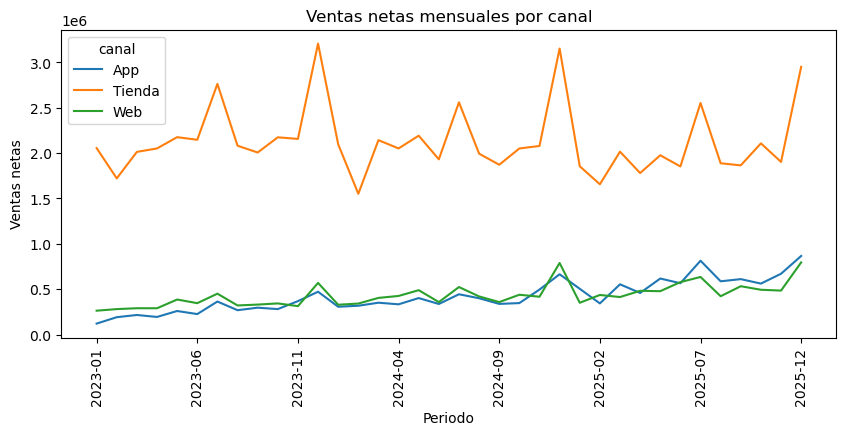

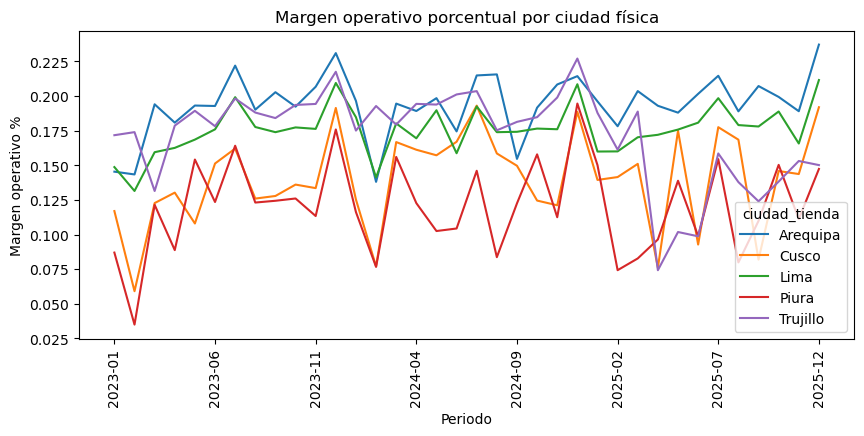

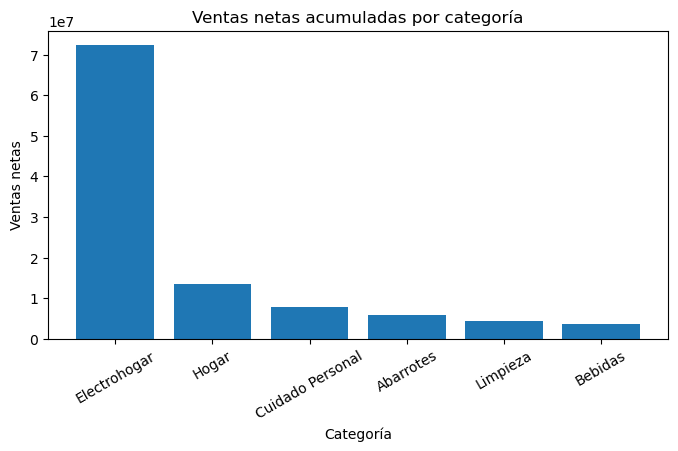

In [8]:
canal_pivot = ventas_canal_mes.pivot(index="periodo_mes", columns="canal", values="ventas_netas").fillna(0)
fig, ax = plt.subplots(figsize=(10, 4))
canal_pivot.plot(ax=ax)
ax.set_title("Ventas netas mensuales por canal")
ax.set_xlabel("Periodo")
ax.set_ylabel("Ventas netas")
ax.tick_params(axis="x", rotation=90)
plt.show()

ciudad_pivot = ciudad_mes.pivot(index="periodo_mes", columns="ciudad_tienda", values="margen_operativo_pct").fillna(0)
fig, ax = plt.subplots(figsize=(10, 4))
ciudad_pivot.plot(ax=ax)
ax.set_title("Margen operativo porcentual por ciudad física")
ax.set_xlabel("Periodo")
ax.set_ylabel("Margen operativo %")
ax.tick_params(axis="x", rotation=90)
plt.show()

categoria_total = ventas_categoria_mes.groupby("categoria", as_index=False)["ventas_netas"].sum().sort_values("ventas_netas", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(categoria_total["categoria"], categoria_total["ventas_netas"])
ax.set_title("Ventas netas acumuladas por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Ventas netas")
ax.tick_params(axis="x", rotation=30)
plt.show()

## 7. Análisis Pareto

Se evalúa la concentración de ventas en productos, categorías y clientes. Este análisis ayuda a identificar elementos que explican una proporción importante del negocio.

In [9]:
def pareto(df: pd.DataFrame, grupo: str, valor: str, nombre_grupo: str) -> pd.DataFrame:
    tabla = (
        df.groupby(grupo, as_index=False)[valor]
        .sum()
        .sort_values(valor, ascending=False)
        .reset_index(drop=True)
    )
    tabla = tabla.rename(columns={grupo: nombre_grupo, valor: "ventas_netas"})
    tabla["ranking"] = np.arange(1, len(tabla) + 1)
    tabla["participacion_pct"] = tabla["ventas_netas"] / tabla["ventas_netas"].sum() * 100
    tabla["participacion_acumulada_pct"] = tabla["participacion_pct"].cumsum()
    return tabla

pareto_productos = pareto(linea, "id_producto", "monto_total", "id_producto")
pareto_productos = pareto_productos.merge(productos[["id_producto", "nombre", "categoria"]], on="id_producto", how="left")
pareto_categorias = pareto(linea, "categoria", "monto_total", "categoria")
pareto_clientes = pareto(linea, "id_cliente", "monto_total", "id_cliente").merge(
    clientes[["id_cliente", "ciudad", "segmento"]], on="id_cliente", how="left"
)

n_productos_80 = int((pareto_productos["participacion_acumulada_pct"] <= 80).sum()) + 1
n_clientes_80 = int((pareto_clientes["participacion_acumulada_pct"] <= 80).sum()) + 1

display(pareto_productos.head(15))
display(pareto_categorias)
display(pareto_clientes.head(15))

display(Markdown(f"""
**Lectura de negocio.** Aproximadamente **{n_productos_80:,} productos** explican cerca del 80% de las ventas netas. A nivel de clientes, se requieren aproximadamente **{n_clientes_80:,} clientes** para explicar el mismo umbral. Esta concentración es útil para priorizar surtido, campañas y análisis de segmentos.
"""))

,id_producto,ventas_netas,ranking,participacion_pct,participacion_acumulada_pct,nombre,categoria
0,P0681,"1,380,351.7200",1,1.2857,1.2857,Electrohogar Lavado AndeTech AJ-744,Electrohogar
1,P0719,"1,330,283.2000",2,1.2391,2.5247,Electrohogar Climatizacion NovaHome PU-120,Electrohogar
2,P0628,"1,276,878.2200",3,1.1893,3.7140,Electrohogar Climatizacion Prisma OJ-436,Electrohogar
3,P0646,"1,227,585.6900",4,1.1434,4.8574,Electrohogar Cocina Prisma TK-365,Electrohogar
4,P0656,"1,224,957.3900",5,1.1409,5.9984,Electrohogar Pequenos electrodomesticos Prisma...,Electrohogar
5,P0691,"1,194,929.3600",6,1.1130,7.1114,Electrohogar Climatizacion Kuntur CJ-170,Electrohogar
6,P0606,"1,191,742.4300",7,1.1100,8.2214,Electrohogar Refrigeracion Prisma YV-430,Electrohogar
7,P0640,"1,165,524.1300",8,1.0856,9.3070,Electrohogar Climatizacion AndeTech DH-706,Electrohogar
8,P0683,"1,153,956.0800",9,1.0748,10.3818,Electrohogar Refrigeracion NovaHome PI-076,Electrohogar
9,P0639,"1,152,297.3800",10,1.0733,11.4551,Electrohogar Refrigeracion AndeTech CV-131,Electrohogar


,categoria,ventas_netas,ranking,participacion_pct,participacion_acumulada_pct
0,Electrohogar,"72,251,805.9700",1,67.2968,67.2968
1,Hogar,"13,378,570.8900",2,12.4611,79.7578
2,Cuidado Personal,"7,857,768.6300",3,7.3189,87.0767
3,Abarrotes,"5,798,083.6500",4,5.4004,92.4771
4,Limpieza,"4,362,578.3200",5,4.0634,96.5405
5,Bebidas,"3,714,179.6500",6,3.4595,100.0000


,id_cliente,ventas_netas,ranking,participacion_pct,participacion_acumulada_pct,ciudad,segmento
0,C14194,"78,967.2400",1,0.0736,0.0736,Lima,Masivo
1,C00699,"70,914.6800",2,0.0661,0.1396,Lima,Masivo
2,C04274,"65,447.4800",3,0.0610,0.2006,Cusco,Preferente
3,C11640,"58,384.3900",4,0.0544,0.2549,Lima,Masivo
4,C09079,"57,429.3300",5,0.0535,0.3084,Trujillo,Masivo
5,C01424,"57,204.6000",6,0.0533,0.3617,Lima,Masivo
6,C00923,"57,031.9100",7,0.0531,0.4148,Trujillo,Preferente
7,C06792,"56,986.7000",8,0.0531,0.4679,Arequipa,Preferente
8,C04404,"56,662.4900",9,0.0528,0.5207,Cusco,Masivo
9,C12794,"55,648.4400",10,0.0518,0.5725,Trujillo,Masivo



**Lectura de negocio.** Aproximadamente **191 productos** explican cerca del 80% de las ventas netas. A nivel de clientes, se requieren aproximadamente **4,536 clientes** para explicar el mismo umbral. Esta concentración es útil para priorizar surtido, campañas y análisis de segmentos.


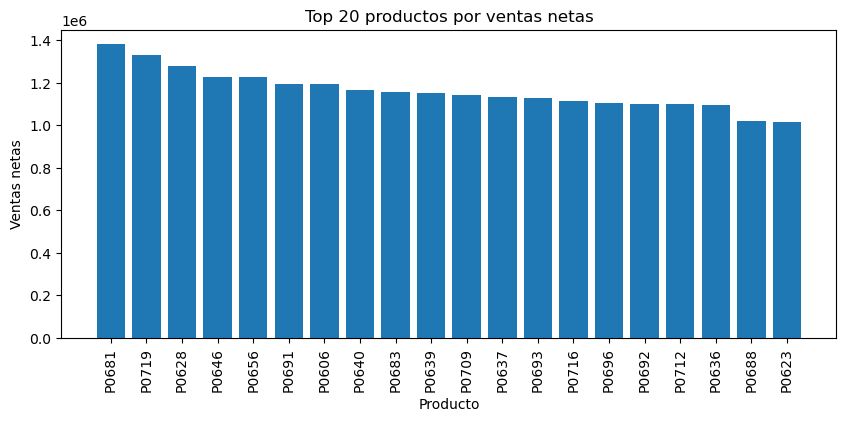

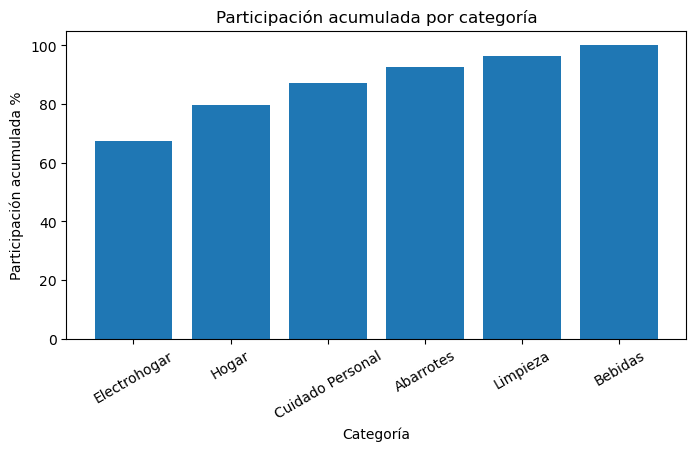

In [10]:
top_productos = pareto_productos.head(20).copy()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top_productos["id_producto"], top_productos["ventas_netas"])
ax.set_title("Top 20 productos por ventas netas")
ax.set_xlabel("Producto")
ax.set_ylabel("Ventas netas")
ax.tick_params(axis="x", rotation=90)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(pareto_categorias["categoria"], pareto_categorias["participacion_acumulada_pct"])
ax.set_title("Participación acumulada por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Participación acumulada %")
ax.tick_params(axis="x", rotation=30)
plt.show()

## 8. Segmentación de clientes mediante RFM

Se usa RFM porque es interpretable y trazable: **Recency** mide días desde la última compra, **Frequency** mide número de tickets y **Monetary** mide valor monetario acumulado. La segmentación no modifica `clientes.csv`; se exporta como resultado derivado.

In [11]:
fecha_corte = pd.Timestamp("2025-12-31")

rfm_base = (
    ticket.groupby("id_cliente", as_index=False)
    .agg(
        fecha_ultima_compra=("fecha_dt", "max"),
        frecuencia=("id_venta", "nunique"),
        valor_monetario=("ticket_total", "sum"),
        ticket_promedio=("ticket_total", "mean"),
        unidades_compradas=("cantidad_total", "sum"),
        canal_mas_reciente=("canal", "last"),
    )
)

segmentacion_clientes = clientes[["id_cliente", "ciudad", "genero", "edad", "segmento", "canal_preferido", "fecha_registro"]].copy()
segmentacion_clientes = segmentacion_clientes.rename(columns={"segmento": "segmento_comercial"})
segmentacion_clientes = segmentacion_clientes.merge(rfm_base, on="id_cliente", how="left")

segmentacion_clientes["frecuencia"] = segmentacion_clientes["frecuencia"].fillna(0).astype(int)
segmentacion_clientes["valor_monetario"] = segmentacion_clientes["valor_monetario"].fillna(0.0)
segmentacion_clientes["ticket_promedio"] = segmentacion_clientes["ticket_promedio"].fillna(0.0)
segmentacion_clientes["unidades_compradas"] = segmentacion_clientes["unidades_compradas"].fillna(0).astype(int)
segmentacion_clientes["fecha_ultima_compra"] = pd.to_datetime(segmentacion_clientes["fecha_ultima_compra"])
segmentacion_clientes["recencia_dias"] = (fecha_corte - segmentacion_clientes["fecha_ultima_compra"]).dt.days
segmentacion_clientes["tiene_compras"] = segmentacion_clientes["frecuencia"] > 0
segmentacion_clientes["inactivo_90d_descriptivo"] = segmentacion_clientes["recencia_dias"].gt(90).fillna(True)

compradores = segmentacion_clientes["tiene_compras"]

def score_quintil_ascendente(serie: pd.Series) -> pd.Series:
    # Puntuación 1-5 robusta ante empates: valores mayores reciben mayor score.
    ranks = serie.rank(method="first")
    return pd.qcut(ranks, q=5, labels=[1, 2, 3, 4, 5]).astype(int)

segmentacion_clientes["r_score"] = 1
segmentacion_clientes["f_score"] = 1
segmentacion_clientes["m_score"] = 1

# Recencia: menor valor es mejor, por eso se invierte el signo.
segmentacion_clientes.loc[compradores, "r_score"] = score_quintil_ascendente(-segmentacion_clientes.loc[compradores, "recencia_dias"])
segmentacion_clientes.loc[compradores, "f_score"] = score_quintil_ascendente(segmentacion_clientes.loc[compradores, "frecuencia"])
segmentacion_clientes.loc[compradores, "m_score"] = score_quintil_ascendente(segmentacion_clientes.loc[compradores, "valor_monetario"])

segmentacion_clientes["rfm_score"] = (
    segmentacion_clientes["r_score"].astype(str)
    + segmentacion_clientes["f_score"].astype(str)
    + segmentacion_clientes["m_score"].astype(str)
)
segmentacion_clientes["rfm_puntaje_total"] = segmentacion_clientes[["r_score", "f_score", "m_score"]].sum(axis=1)

def asignar_segmento_rfm(row: pd.Series) -> str:
    if not row["tiene_compras"]:
        return "Sin compra"
    r, f, m = int(row["r_score"]), int(row["f_score"]), int(row["m_score"])
    if r >= 4 and f >= 4 and m >= 4:
        return "Campeones"
    if r >= 3 and f >= 4:
        return "Leales"
    if m >= 4 and f >= 3:
        return "Alto valor"
    if r <= 2 and (f >= 3 or m >= 3):
        return "En riesgo"
    if r >= 4 and f <= 2:
        return "Nuevos o prometedores"
    if r <= 2 and f <= 2 and m <= 2:
        return "Bajo valor"
    return "Regular"

segmentacion_clientes["segmento_rfm"] = segmentacion_clientes.apply(asignar_segmento_rfm, axis=1)

columnas_segmentacion = [
    "id_cliente", "ciudad", "genero", "edad", "segmento_comercial", "canal_preferido",
    "fecha_registro", "fecha_ultima_compra", "recencia_dias", "frecuencia",
    "valor_monetario", "ticket_promedio", "unidades_compradas", "r_score", "f_score",
    "m_score", "rfm_score", "rfm_puntaje_total", "segmento_rfm",
    "inactivo_90d_descriptivo", "tiene_compras",
]
segmentacion_clientes = segmentacion_clientes[columnas_segmentacion]

resumen_segmentos = (
    segmentacion_clientes.groupby("segmento_rfm", as_index=False)
    .agg(
        clientes=("id_cliente", "count"),
        valor_monetario_total=("valor_monetario", "sum"),
        frecuencia_media=("frecuencia", "mean"),
        recencia_media_dias=("recencia_dias", "mean"),
        ticket_promedio=("ticket_promedio", "mean"),
        inactivos_90d=("inactivo_90d_descriptivo", "mean"),
    )
    .sort_values("valor_monetario_total", ascending=False)
)
resumen_segmentos["participacion_clientes_pct"] = resumen_segmentos["clientes"] / resumen_segmentos["clientes"].sum() * 100
resumen_segmentos["participacion_valor_pct"] = resumen_segmentos["valor_monetario_total"] / resumen_segmentos["valor_monetario_total"].sum() * 100
resumen_segmentos["inactivos_90d_pct"] = resumen_segmentos["inactivos_90d"] * 100

segmentacion_clientes.to_csv(OUT_SEGMENTACION, index=False, encoding="utf-8-sig")

display(resumen_segmentos)
display(segmentacion_clientes.head())
print(f"Archivo exportado: {OUT_SEGMENTACION.relative_to(ROOT)}")

,segmento_rfm,clientes,valor_monetario_total,frecuencia_media,recencia_media_dias,ticket_promedio,inactivos_90d,participacion_clientes_pct,participacion_valor_pct,inactivos_90d_pct
0,Alto valor,1070,"23,812,054.7000",14.8364,89.4794,"1,524.0718",0.4308,7.1333,22.1790,43.0841
2,Campeones,898,"20,549,075.5900",17.3318,11.8641,"1,336.5318",0.0000,5.9867,19.1398,0.0000
3,En riesgo,1345,"18,103,650.2900",12.4543,139.7152,"1,196.1740",0.7294,8.9667,16.8621,72.9368
4,Leales,1239,"17,836,799.8300",16.4705,27.7425,872.1699,0.0000,8.2600,16.6135,0.0000
6,Regular,1104,"10,877,133.7000",11.6685,32.7645,862.5636,0.0000,7.3600,10.1312,0.0000
5,Nuevos o prometedores,924,"10,037,810.0600",10.3474,12.3387,"1,050.3876",0.0000,6.1600,9.3494,0.0000
1,Bajo valor,969,"6,146,462.9400",9.2466,165.3313,699.8287,0.8101,6.4600,5.7249,81.0114
7,Sin compra,7451,0.0000,0.0000,NaN,0.0000,0.0000,49.6733,0.0000,0.0000


,id_cliente,ciudad,genero,edad,segmento_comercial,canal_preferido,fecha_registro,fecha_ultima_compra,recencia_dias,frecuencia,...,ticket_promedio,unidades_compradas,r_score,f_score,m_score,rfm_score,rfm_puntaje_total,segmento_rfm,inactivo_90d_descriptivo,tiene_compras
0,C03710,Lima,M,38.0000,Masivo,Web,2020-01-01,2025-12-13,18.0000,16,...,954.6688,82,4,4,4,444,12,Campeones,False,True
1,C11257,Lima,M,36.0000,Preferente,Web,2020-01-01,2025-12-21,10.0000,15,...,"1,351.3427",96,5,4,5,545,14,Campeones,False,True
2,C06256,Arequipa,M,25.0000,Masivo,Web,2020-01-02,2025-06-13,201.0000,6,...,"1,905.2383",38,1,1,3,113,5,En riesgo,True,True
3,C10738,Arequipa,F,44.0000,Masivo,Tienda,2020-01-02,2025-12-30,1.0000,11,...,"1,895.9645",71,5,2,5,525,12,Nuevos o prometedores,False,True
4,C11997,Lima,F,57.0000,Masivo,Tienda,2020-01-02,2025-12-31,0.0000,12,...,712.5200,44,5,2,2,522,9,Nuevos o prometedores,False,True


Archivo exportado: resultados\segmentacion_clientes.csv


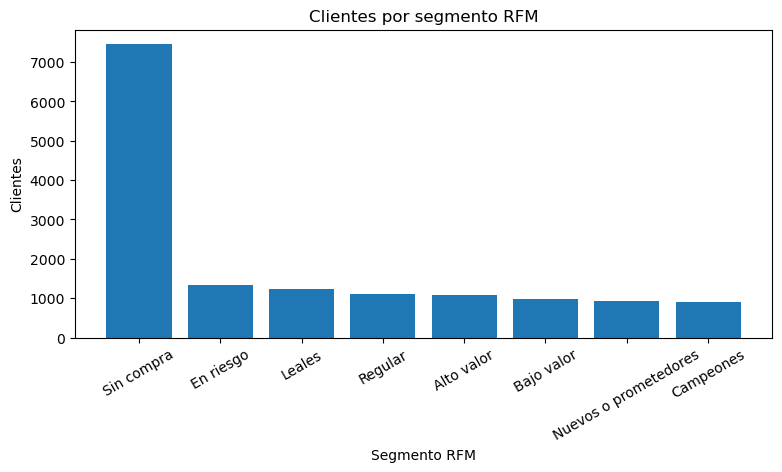

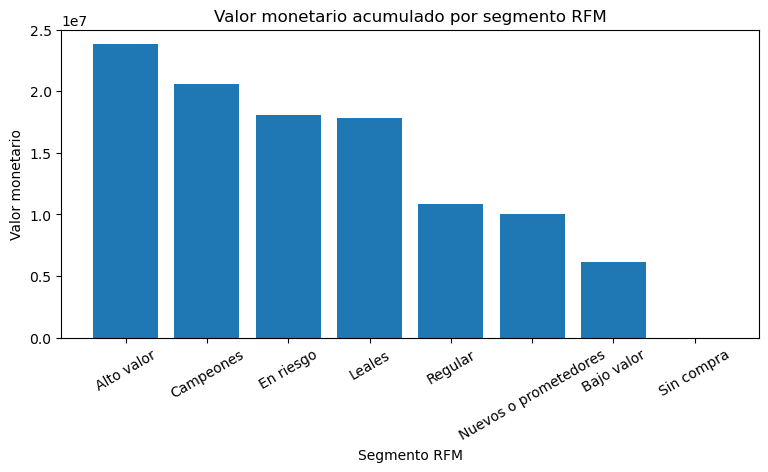


**Lectura de negocio.** El segmento que concentra mayor valor monetario es **Alto valor**, con **22.18%** del valor acumulado. Esta segmentación puede usarse en Power BI para priorizar campañas, retención y análisis de churn posterior.


In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
segmentos_orden = resumen_segmentos.sort_values("clientes", ascending=False)
ax.bar(segmentos_orden["segmento_rfm"], segmentos_orden["clientes"])
ax.set_title("Clientes por segmento RFM")
ax.set_xlabel("Segmento RFM")
ax.set_ylabel("Clientes")
ax.tick_params(axis="x", rotation=30)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
segmentos_valor = resumen_segmentos.sort_values("valor_monetario_total", ascending=False)
ax.bar(segmentos_valor["segmento_rfm"], segmentos_valor["valor_monetario_total"])
ax.set_title("Valor monetario acumulado por segmento RFM")
ax.set_xlabel("Segmento RFM")
ax.set_ylabel("Valor monetario")
ax.tick_params(axis="x", rotation=30)
plt.show()

top_segmento = resumen_segmentos.iloc[0]
display(Markdown(f"""
**Lectura de negocio.** El segmento que concentra mayor valor monetario es **{top_segmento['segmento_rfm']}**, con **{top_segmento['participacion_valor_pct']:.2f}%** del valor acumulado. Esta segmentación puede usarse en Power BI para priorizar campañas, retención y análisis de churn posterior.
"""))

## 9. Diagnóstico de Trujillo desde 2025-Q2

La especificación indica que la caída de Trujillo debe analizarse sobre tiendas físicas y mediante margen operativo porcentual. Se comparan 2025-Q1 y 2025-Q2, y se evalúan tres causas: descuentos, mezcla de categorías y costos de almacenamiento.

In [13]:
# Resumen ciudad-trimestre para tiendas físicas.
ventas_ciudad_trimestre = (
    linea_fisica.groupby(["ciudad_tienda", "trimestre"], as_index=False)
    .agg(
        ventas_netas=("monto_total", "sum"),
        margen_bruto=("margen_bruto", "sum"),
        descuento_monto=("descuento_monto", "sum"),
        venta_bruta=("venta_bruta", "sum"),
        costo_mercaderia=("costo_mercaderia", "sum"),
        unidades=("cantidad", "sum"),
        lineas=("id_linea", "count"),
        tickets=("id_venta", "nunique"),
    )
)

costo_ciudad_trimestre = (
    inventario_fisico.groupby(["ciudad_tienda", "trimestre"], as_index=False)["costo_almacenamiento"]
    .sum()
)

ciudad_trimestre = ventas_ciudad_trimestre.merge(
    costo_ciudad_trimestre,
    on=["ciudad_tienda", "trimestre"],
    how="left",
)
ciudad_trimestre["costo_almacenamiento"] = ciudad_trimestre["costo_almacenamiento"].fillna(0)
ciudad_trimestre["margen_operativo"] = ciudad_trimestre["margen_bruto"] - ciudad_trimestre["costo_almacenamiento"]
ciudad_trimestre["margen_operativo_pct"] = ciudad_trimestre["margen_operativo"] / ciudad_trimestre["ventas_netas"]
ciudad_trimestre["margen_bruto_pct"] = ciudad_trimestre["margen_bruto"] / ciudad_trimestre["ventas_netas"]
ciudad_trimestre["descuento_pct_ponderado"] = ciudad_trimestre["descuento_monto"] / ciudad_trimestre["venta_bruta"]
ciudad_trimestre["costo_almacenamiento_pct_ventas"] = ciudad_trimestre["costo_almacenamiento"] / ciudad_trimestre["ventas_netas"]

q1q2 = ciudad_trimestre[ciudad_trimestre["trimestre"].isin(["2025Q1", "2025Q2"])].copy()
trujillo_q1q2 = q1q2[q1q2["ciudad_tienda"].eq("Trujillo")].copy()

display(q1q2.sort_values(["ciudad_tienda", "trimestre"]))

trujillo_q1 = trujillo_q1q2[trujillo_q1q2["trimestre"].eq("2025Q1")].iloc[0]
trujillo_q2 = trujillo_q1q2[trujillo_q1q2["trimestre"].eq("2025Q2")].iloc[0]
caida_margen_pp = (trujillo_q2["margen_operativo_pct"] - trujillo_q1["margen_operativo_pct"]) * 100

display(Markdown(f"""
**Lectura de negocio.** El margen operativo porcentual de Trujillo pasa de **{trujillo_q1['margen_operativo_pct']*100:.2f}%** en 2025-Q1 a **{trujillo_q2['margen_operativo_pct']*100:.2f}%** en 2025-Q2. La variación es de **{caida_margen_pp:.2f} puntos porcentuales**, consistente con el patrón diagnóstico definido para el caso.
"""))

,ciudad_tienda,trimestre,ventas_netas,margen_bruto,descuento_monto,venta_bruta,costo_mercaderia,unidades,lineas,tickets,costo_almacenamiento,margen_operativo,margen_operativo_pct,margen_bruto_pct,descuento_pct_ponderado,costo_almacenamiento_pct_ventas
8,Arequipa,2025Q1,"1,175,449.8300","327,301.0500","42,492.0232","1,217,941.8300","848,148.7800",5121,2493,989,"99,217.3500","228,083.7000",0.1940,0.2784,0.0349,0.0844
9,Arequipa,2025Q2,"1,194,428.1900","331,442.6000","41,176.3173","1,235,604.5900","862,985.5900",5622,2788,1106,"99,217.3500","232,225.2500",0.1944,0.2775,0.0333,0.0831
20,Cusco,2025Q1,"680,929.2000","191,314.0900","20,342.8587","701,272.1800","489,615.1100",3223,1534,611,"93,049.2300","98,264.8600",0.1443,0.2810,0.0290,0.1367
21,Cusco,2025Q2,"621,679.9800","172,096.4200","22,517.8115","644,197.9400","449,583.5600",3311,1599,650,"93,013.0500","79,083.3700",0.1272,0.2768,0.0350,0.1496
32,Lima,2025Q1,"2,136,199.5000","593,072.4200","71,660.3587","2,207,859.8900","1,543,127.0800",10769,5141,2072,"243,355.0100","349,717.4100",0.1637,0.2776,0.0325,0.1139
33,Lima,2025Q2,"2,416,067.3300","669,193.7100","81,497.1359","2,497,564.6400","1,746,873.6200",11495,5616,2263,"243,340.4200","425,853.2900",0.1763,0.2770,0.0326,0.1007
44,Piura,2025Q1,"520,825.4800","146,416.8000","16,655.0998","537,480.5100","374,408.6800",2448,1236,505,"89,505.3700","56,911.4300",0.1093,0.2811,0.0310,0.1719
45,Piura,2025Q2,"550,998.2600","152,070.7600","19,789.8880","570,788.2200","398,927.5000",2899,1404,546,"89,429.9000","62,640.8600",0.1137,0.2760,0.0347,0.1623
56,Trujillo,2025Q1,"1,013,255.7700","279,151.9400","37,202.8058","1,050,458.4800","734,103.8300",5063,2434,951,"95,478.3300","183,673.6100",0.1813,0.2755,0.0354,0.0942
57,Trujillo,2025Q2,"825,451.6500","182,994.0100","86,807.4349","912,259.1500","642,457.6400",5043,2384,935,"106,980.6300","76,013.3800",0.0921,0.2217,0.0952,0.1296



**Lectura de negocio.** El margen operativo porcentual de Trujillo pasa de **18.13%** en 2025-Q1 a **9.21%** en 2025-Q2. La variación es de **-8.92 puntos porcentuales**, consistente con el patrón diagnóstico definido para el caso.


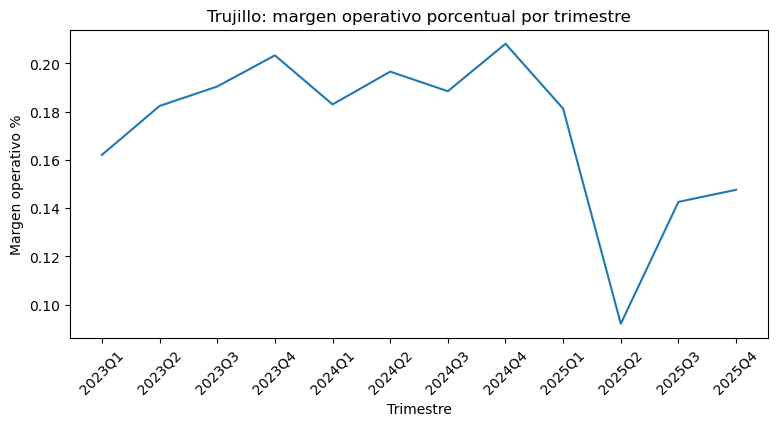

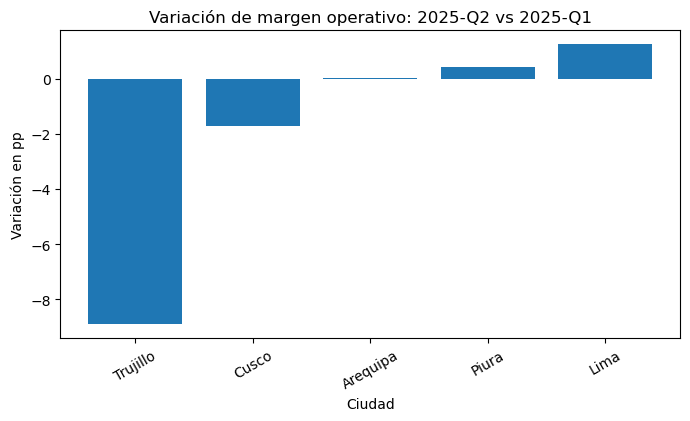

trimestre,ciudad_tienda,2025Q1,2025Q2,delta_q2_vs_q1_pp
4,Trujillo,0.1813,0.0921,-8.9184
1,Cusco,0.1443,0.1272,-1.7101
0,Arequipa,0.1940,0.1944,0.0384
3,Piura,0.1093,0.1137,0.4415
2,Lima,0.1637,0.1763,1.2549


In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
trujillo_tendencia = ciudad_trimestre[ciudad_trimestre["ciudad_tienda"].eq("Trujillo")].copy()
ax.plot(trujillo_tendencia["trimestre"], trujillo_tendencia["margen_operativo_pct"])
ax.set_title("Trujillo: margen operativo porcentual por trimestre")
ax.set_xlabel("Trimestre")
ax.set_ylabel("Margen operativo %")
ax.tick_params(axis="x", rotation=45)
plt.show()

comparativo_q1q2 = q1q2.pivot(index="ciudad_tienda", columns="trimestre", values="margen_operativo_pct").reset_index()
comparativo_q1q2["delta_q2_vs_q1_pp"] = (comparativo_q1q2["2025Q2"] - comparativo_q1q2["2025Q1"]) * 100
comparativo_q1q2 = comparativo_q1q2.sort_values("delta_q2_vs_q1_pp")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comparativo_q1q2["ciudad_tienda"], comparativo_q1q2["delta_q2_vs_q1_pp"])
ax.set_title("Variación de margen operativo: 2025-Q2 vs 2025-Q1")
ax.set_xlabel("Ciudad")
ax.set_ylabel("Variación en pp")
ax.tick_params(axis="x", rotation=30)
plt.show()

display(comparativo_q1q2)

## 10. Causas del deterioro de Trujillo

Se evalúan los tres mecanismos causales definidos: mayor descuento, cambio en mezcla de categorías hacia categorías de menor margen y mayor costo de almacenamiento.

In [15]:
# Mezcla de categorías en Trujillo por trimestre.
trujillo_linea = linea_fisica[linea_fisica["ciudad_tienda"].eq("Trujillo")].copy()
trujillo_mix = (
    trujillo_linea.groupby(["trimestre", "categoria"], as_index=False)
    .agg(
        ventas_netas=("monto_total", "sum"),
        margen_bruto=("margen_bruto", "sum"),
        descuento_monto=("descuento_monto", "sum"),
        venta_bruta=("venta_bruta", "sum"),
        unidades=("cantidad", "sum"),
    )
)
trujillo_mix["participacion_ventas_pct"] = (
    trujillo_mix["ventas_netas"]
    / trujillo_mix.groupby("trimestre")["ventas_netas"].transform("sum")
    * 100
)
trujillo_mix["margen_bruto_pct_categoria"] = trujillo_mix["margen_bruto"] / trujillo_mix["ventas_netas"]
trujillo_mix["descuento_pct_ponderado_categoria"] = trujillo_mix["descuento_monto"] / trujillo_mix["venta_bruta"]

mix_q1q2 = trujillo_mix[trujillo_mix["trimestre"].isin(["2025Q1", "2025Q2"])].copy()

mix_pivot = (
    mix_q1q2.pivot(index="categoria", columns="trimestre", values="participacion_ventas_pct")
    .reset_index()
    .fillna(0)
)
mix_pivot["delta_participacion_pp"] = mix_pivot["2025Q2"] - mix_pivot["2025Q1"]
margen_cat_q2 = mix_q1q2[mix_q1q2["trimestre"].eq("2025Q2")][["categoria", "margen_bruto_pct_categoria"]]
mix_pivot = mix_pivot.merge(margen_cat_q2, on="categoria", how="left")
mix_pivot = mix_pivot.sort_values("delta_participacion_pp", ascending=False)

display(mix_pivot)

categorias_bajo_margen = ["Abarrotes", "Bebidas"]
participacion_bajo_margen = (
    mix_q1q2[mix_q1q2["categoria"].isin(categorias_bajo_margen)]
    .groupby("trimestre")["ventas_netas"].sum()
    / mix_q1q2.groupby("trimestre")["ventas_netas"].sum()
    * 100
)
part_bajo_q1 = float(participacion_bajo_margen.loc["2025Q1"])
part_bajo_q2 = float(participacion_bajo_margen.loc["2025Q2"])

delta_descuento_pp = (trujillo_q2["descuento_pct_ponderado"] - trujillo_q1["descuento_pct_ponderado"]) * 100
delta_costo_pct_ventas_pp = (trujillo_q2["costo_almacenamiento_pct_ventas"] - trujillo_q1["costo_almacenamiento_pct_ventas"]) * 100
delta_mix_bajo_margen_pp = part_bajo_q2 - part_bajo_q1

causas = pd.DataFrame([
    {
        "causa": "Descuentos",
        "metrica": "descuento_pct_ponderado",
        "valor_2025Q1_pct": trujillo_q1["descuento_pct_ponderado"] * 100,
        "valor_2025Q2_pct": trujillo_q2["descuento_pct_ponderado"] * 100,
        "delta_pp": delta_descuento_pp,
        "interpretacion": "El mayor descuento reduce directamente la venta neta y presiona el margen.",
    },
    {
        "causa": "Mezcla de productos",
        "metrica": "participacion_abarrotes_bebidas_pct",
        "valor_2025Q1_pct": part_bajo_q1,
        "valor_2025Q2_pct": part_bajo_q2,
        "delta_pp": delta_mix_bajo_margen_pp,
        "interpretacion": "La mayor participación de Abarrotes y Bebidas desplaza ventas hacia categorías de menor margen base.",
    },
    {
        "causa": "Costo de almacenamiento",
        "metrica": "costo_almacenamiento_pct_ventas",
        "valor_2025Q1_pct": trujillo_q1["costo_almacenamiento_pct_ventas"] * 100,
        "valor_2025Q2_pct": trujillo_q2["costo_almacenamiento_pct_ventas"] * 100,
        "delta_pp": delta_costo_pct_ventas_pp,
        "interpretacion": "El mayor costo de almacenamiento reduce el margen operativo, aunque no afecta el margen bruto.",
    },
    {
        "causa": "Resultado final",
        "metrica": "margen_operativo_pct",
        "valor_2025Q1_pct": trujillo_q1["margen_operativo_pct"] * 100,
        "valor_2025Q2_pct": trujillo_q2["margen_operativo_pct"] * 100,
        "delta_pp": caida_margen_pp,
        "interpretacion": "El efecto conjunto de descuentos, mezcla y almacenamiento explica la caída del margen operativo.",
    },
])

display(causas)

display(Markdown(f"""
**Diagnóstico de negocio.** Entre 2025-Q1 y 2025-Q2, Trujillo combina tres presiones: el descuento ponderado cambia en **{delta_descuento_pp:.2f} pp**, la participación de Abarrotes y Bebidas cambia en **{delta_mix_bajo_margen_pp:.2f} pp**, y el costo de almacenamiento sobre ventas cambia en **{delta_costo_pct_ventas_pp:.2f} pp**. La consecuencia agregada es una caída de **{caida_margen_pp:.2f} pp** en margen operativo.
"""))

,categoria,2025Q1,2025Q2,delta_participacion_pp,margen_bruto_pct_categoria
0,Abarrotes,5.5452,7.1692,1.6240,0.1150
1,Bebidas,3.6475,5.0337,1.3862,0.1622
3,Electrohogar,64.9705,66.2636,1.2930,0.2217
5,Limpieza,4.0665,3.8553,-0.2112,0.2408
2,Cuidado Personal,7.5410,6.9820,-0.5590,0.3030
4,Hogar,14.2292,10.6962,-3.5330,0.2611


,causa,metrica,valor_2025Q1_pct,valor_2025Q2_pct,delta_pp,interpretacion
0,Descuentos,descuento_pct_ponderado,3.5416,9.5157,5.9741,El mayor descuento reduce directamente la vent...
1,Mezcla de productos,participacion_abarrotes_bebidas_pct,9.1927,12.2029,3.0102,La mayor participación de Abarrotes y Bebidas ...
2,Costo de almacenamiento,costo_almacenamiento_pct_ventas,9.4229,12.9603,3.5373,El mayor costo de almacenamiento reduce el mar...
3,Resultado final,margen_operativo_pct,18.1271,9.2087,-8.9184,"El efecto conjunto de descuentos, mezcla y alm..."



**Diagnóstico de negocio.** Entre 2025-Q1 y 2025-Q2, Trujillo combina tres presiones: el descuento ponderado cambia en **5.97 pp**, la participación de Abarrotes y Bebidas cambia en **3.01 pp**, y el costo de almacenamiento sobre ventas cambia en **3.54 pp**. La consecuencia agregada es una caída de **-8.92 pp** en margen operativo.


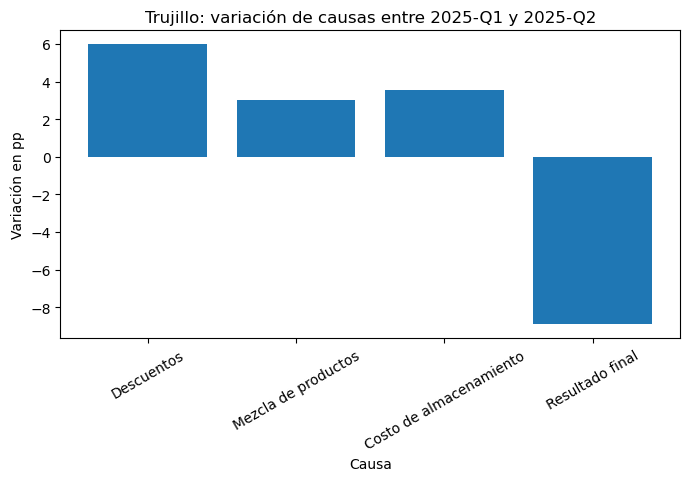

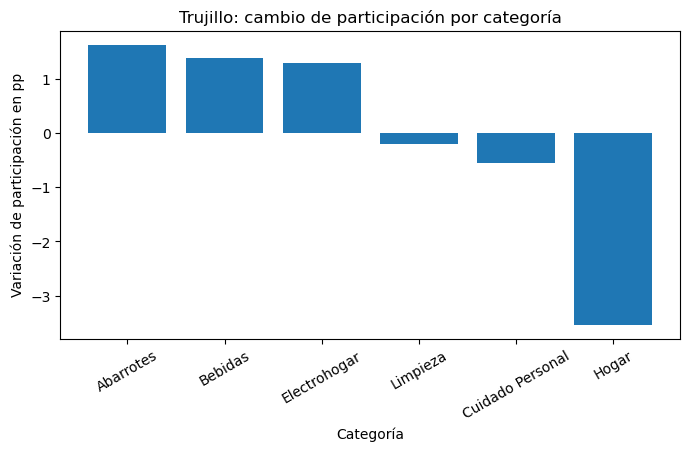

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(causas["causa"], causas["delta_pp"])
ax.set_title("Trujillo: variación de causas entre 2025-Q1 y 2025-Q2")
ax.set_xlabel("Causa")
ax.set_ylabel("Variación en pp")
ax.tick_params(axis="x", rotation=30)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(mix_pivot["categoria"], mix_pivot["delta_participacion_pp"])
ax.set_title("Trujillo: cambio de participación por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Variación de participación en pp")
ax.tick_params(axis="x", rotation=30)
plt.show()

## 11. Exportación de diagnóstico de Trujillo

Se genera `diagnostico_trujillo.csv` en formato largo. El archivo consolida el resumen ciudad-trimestre, el cambio de mezcla por categoría y las causas principales del deterioro. Este formato facilita su consumo posterior en Power BI y en la Parte 4.

In [17]:
filas_diagnostico = []

# Bloque 1: resumen ciudad-trimestre Q1/Q2 2025.
for _, row in q1q2.iterrows():
    filas_diagnostico.append({
        "bloque": "resumen_ciudad_trimestre",
        "ciudad": row["ciudad_tienda"],
        "periodo": row["trimestre"],
        "categoria": "Todas",
        "causa": "margen_operativo",
        "metrica": "resumen_financiero",
        "valor_2025Q1_pct": np.nan,
        "valor_2025Q2_pct": np.nan,
        "delta_pp": np.nan,
        "ventas_netas": row["ventas_netas"],
        "margen_bruto": row["margen_bruto"],
        "costo_almacenamiento": row["costo_almacenamiento"],
        "margen_operativo": row["margen_operativo"],
        "margen_operativo_pct": row["margen_operativo_pct"] * 100,
        "descuento_pct_ponderado": row["descuento_pct_ponderado"] * 100,
        "costo_almacenamiento_pct_ventas": row["costo_almacenamiento_pct_ventas"] * 100,
        "participacion_ventas_pct": np.nan,
        "margen_bruto_pct_categoria": np.nan,
        "interpretacion": "Resumen trimestral de margen operativo por ciudad física.",
    })

# Bloque 2: mezcla por categoría en Trujillo.
for _, row in mix_pivot.iterrows():
    filas_diagnostico.append({
        "bloque": "trujillo_mix_categoria",
        "ciudad": "Trujillo",
        "periodo": "2025Q1_vs_2025Q2",
        "categoria": row["categoria"],
        "causa": "mezcla_productos",
        "metrica": "participacion_ventas_categoria",
        "valor_2025Q1_pct": row["2025Q1"],
        "valor_2025Q2_pct": row["2025Q2"],
        "delta_pp": row["delta_participacion_pp"],
        "ventas_netas": np.nan,
        "margen_bruto": np.nan,
        "costo_almacenamiento": np.nan,
        "margen_operativo": np.nan,
        "margen_operativo_pct": np.nan,
        "descuento_pct_ponderado": np.nan,
        "costo_almacenamiento_pct_ventas": np.nan,
        "participacion_ventas_pct": row["2025Q2"],
        "margen_bruto_pct_categoria": row["margen_bruto_pct_categoria"] * 100,
        "interpretacion": "Cambio de participación de la categoría dentro de las ventas físicas de Trujillo.",
    })

# Bloque 3: causas principales.
for _, row in causas.iterrows():
    filas_diagnostico.append({
        "bloque": "trujillo_causas_q1_q2",
        "ciudad": "Trujillo",
        "periodo": "2025Q1_vs_2025Q2",
        "categoria": "Todas",
        "causa": row["causa"],
        "metrica": row["metrica"],
        "valor_2025Q1_pct": row["valor_2025Q1_pct"],
        "valor_2025Q2_pct": row["valor_2025Q2_pct"],
        "delta_pp": row["delta_pp"],
        "ventas_netas": np.nan,
        "margen_bruto": np.nan,
        "costo_almacenamiento": np.nan,
        "margen_operativo": np.nan,
        "margen_operativo_pct": np.nan,
        "descuento_pct_ponderado": np.nan,
        "costo_almacenamiento_pct_ventas": np.nan,
        "participacion_ventas_pct": np.nan,
        "margen_bruto_pct_categoria": np.nan,
        "interpretacion": row["interpretacion"],
    })

diagnostico_trujillo = pd.DataFrame(filas_diagnostico)
diagnostico_trujillo.to_csv(OUT_DIAGNOSTICO, index=False, encoding="utf-8-sig")

display(diagnostico_trujillo.head(20))
print(f"Archivo exportado: {OUT_DIAGNOSTICO.relative_to(ROOT)}")

,bloque,ciudad,periodo,categoria,causa,metrica,valor_2025Q1_pct,valor_2025Q2_pct,delta_pp,ventas_netas,margen_bruto,costo_almacenamiento,margen_operativo,margen_operativo_pct,descuento_pct_ponderado,costo_almacenamiento_pct_ventas,participacion_ventas_pct,margen_bruto_pct_categoria,interpretacion
0,resumen_ciudad_trimestre,Arequipa,2025Q1,Todas,margen_operativo,resumen_financiero,NaN,NaN,NaN,"1,175,449.8300","327,301.0500","99,217.3500","228,083.7000",19.4040,3.4888,8.4408,NaN,NaN,Resumen trimestral de margen operativo por ciu...
1,resumen_ciudad_trimestre,Arequipa,2025Q2,Todas,margen_operativo,resumen_financiero,NaN,NaN,NaN,"1,194,428.1900","331,442.6000","99,217.3500","232,225.2500",19.4424,3.3325,8.3067,NaN,NaN,Resumen trimestral de margen operativo por ciu...
2,resumen_ciudad_trimestre,Cusco,2025Q1,Todas,margen_operativo,resumen_financiero,NaN,NaN,NaN,"680,929.2000","191,314.0900","93,049.2300","98,264.8600",14.4310,2.9009,13.6650,NaN,NaN,Resumen trimestral de margen operativo por ciu...
3,resumen_ciudad_trimestre,Cusco,2025Q2,Todas,margen_operativo,resumen_financiero,NaN,NaN,NaN,"621,679.9800","172,096.4200","93,013.0500","79,083.3700",12.7209,3.4955,14.9616,NaN,NaN,Resumen trimestral de margen operativo por ciu...
4,resumen_ciudad_trimestre,Lima,2025Q1,Todas,margen_operativo,resumen_financiero,NaN,NaN,NaN,"2,136,199.5000","593,072.4200","243,355.0100","349,717.4100",16.3710,3.2457,11.3920,NaN,NaN,Resumen trimestral de margen operativo por ciu...
5,resumen_ciudad_trimestre,Lima,2025Q2,Todas,margen_operativo,resumen_financiero,NaN,NaN,NaN,"2,416,067.3300","669,193.7100","243,340.4200","425,853.2900",17.6259,3.2631,10.0718,NaN,NaN,Resumen trimestral de margen operativo por ciu...
6,resumen_ciudad_trimestre,Piura,2025Q1,Todas,margen_operativo,resumen_financiero,NaN,NaN,NaN,"520,825.4800","146,416.8000","89,505.3700","56,911.4300",10.9272,3.0987,17.1853,NaN,NaN,Resumen trimestral de margen operativo por ciu...
7,resumen_ciudad_trimestre,Piura,2025Q2,Todas,margen_operativo,resumen_financiero,NaN,NaN,NaN,"550,998.2600","152,070.7600","89,429.9000","62,640.8600",11.3686,3.4671,16.2305,NaN,NaN,Resumen trimestral de margen operativo por ciu...
8,resumen_ciudad_trimestre,Trujillo,2025Q1,Todas,margen_operativo,resumen_financiero,NaN,NaN,NaN,"1,013,255.7700","279,151.9400","95,478.3300","183,673.6100",18.1271,3.5416,9.4229,NaN,NaN,Resumen trimestral de margen operativo por ciu...
9,resumen_ciudad_trimestre,Trujillo,2025Q2,Todas,margen_operativo,resumen_financiero,NaN,NaN,NaN,"825,451.6500","182,994.0100","106,980.6300","76,013.3800",9.2087,9.5157,12.9603,NaN,NaN,Resumen trimestral de margen operativo por ciu...


Archivo exportado: resultados\diagnostico_trujillo.csv


## 12. Conclusiones ejecutivas

Se resumen los hallazgos de la Parte 2 para facilitar la defensa del trabajo y la integración posterior en Power BI.

In [18]:
ventas_por_canal_total = ventas_canal_mes.groupby("canal", as_index=False)["ventas_netas"].sum()
ventas_por_canal_total["participacion_pct"] = ventas_por_canal_total["ventas_netas"] / ventas_por_canal_total["ventas_netas"].sum() * 100
canal_lider = ventas_por_canal_total.sort_values("ventas_netas", ascending=False).iloc[0]

categoria_lider = pareto_categorias.iloc[0]
segmento_lider = resumen_segmentos.iloc[0]

conclusiones = f"""
### Conclusiones de negocio

1. **Tendencia general.** Las ventas netas muestran crecimiento acumulado entre 2023 y 2025, con estacionalidad mensual visible y picos comerciales en meses clave.
2. **Canal líder.** El canal con mayor venta acumulada es **{canal_lider['canal']}**, con **{canal_lider['participacion_pct']:.2f}%** de participación sobre ventas netas.
3. **Categoría líder.** La categoría con mayor venta acumulada es **{categoria_lider['categoria']}**, con **{categoria_lider['participacion_pct']:.2f}%** de participación.
4. **Segmentación.** El segmento RFM de mayor valor monetario es **{segmento_lider['segmento_rfm']}**, que concentra **{segmento_lider['participacion_valor_pct']:.2f}%** del valor monetario acumulado.
5. **Trujillo.** La caída de margen operativo de Trujillo entre 2025-Q1 y 2025-Q2 es de **{caida_margen_pp:.2f} pp**. El diagnóstico la asocia con el efecto conjunto de descuentos, mezcla de categorías y costos de almacenamiento.

Los archivos derivados generados por esta parte son `segmentacion_clientes.csv` y `diagnostico_trujillo.csv`.
"""
display(Markdown(conclusiones))


### Conclusiones de negocio

1. **Tendencia general.** Las ventas netas muestran crecimiento acumulado entre 2023 y 2025, con estacionalidad mensual visible y picos comerciales en meses clave.
2. **Canal líder.** El canal con mayor venta acumulada es **Tienda**, con **71.36%** de participación sobre ventas netas.
3. **Categoría líder.** La categoría con mayor venta acumulada es **Electrohogar**, con **67.30%** de participación.
4. **Segmentación.** El segmento RFM de mayor valor monetario es **Alto valor**, que concentra **22.18%** del valor monetario acumulado.
5. **Trujillo.** La caída de margen operativo de Trujillo entre 2025-Q1 y 2025-Q2 es de **-8.92 pp**. El diagnóstico la asocia con el efecto conjunto de descuentos, mezcla de categorías y costos de almacenamiento.

Los archivos derivados generados por esta parte son `segmentacion_clientes.csv` y `diagnostico_trujillo.csv`.


## 13. Control final de entregables

Se valida que los archivos requeridos existan y tengan contenido. La existencia de estos archivos permite continuar con P3, P4 y P5 sin modificar el dataset oficial v1.

In [19]:
assert OUT_SEGMENTACION.exists(), f"No se generó {OUT_SEGMENTACION}"
assert OUT_DIAGNOSTICO.exists(), f"No se generó {OUT_DIAGNOSTICO}"
assert len(segmentacion_clientes) == len(clientes), "La segmentación no contiene todos los clientes."
assert len(diagnostico_trujillo) > 0, "El diagnóstico de Trujillo quedó vacío."

control_entregables = pd.DataFrame([
    {"archivo": str(OUT_SEGMENTACION.relative_to(ROOT)), "filas": len(segmentacion_clientes), "columnas": segmentacion_clientes.shape[1]},
    {"archivo": str(OUT_DIAGNOSTICO.relative_to(ROOT)), "filas": len(diagnostico_trujillo), "columnas": diagnostico_trujillo.shape[1]},
])
display(control_entregables)
print("[OK] Parte 2 ejecutada correctamente.")

,archivo,filas,columnas
0,resultados\segmentacion_clientes.csv,15000,21
1,resultados\diagnostico_trujillo.csv,20,19


[OK] Parte 2 ejecutada correctamente.
